In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import configparser
import time
from math import ceil

import cv2
import imutils
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import layers
from keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications.efficientnet import EfficientNetB1
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Activation, BatchNormalization


from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix as cm, classification_report as cr
import numpy as np
import random
import os
from tqdm import tqdm
import pickle
import cv2

import torch
import torch.nn as nn
from torchvision import models
import pickle
import torchvision.transforms as transforms

In [ ]:
!unzip /content/drive/MyDrive/real_images.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: archive/Training/meningioma_tumor/m3 (117).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m3 (117).jpg  
  inflating: archive/Training/meningioma_tumor/m1(153).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m1(153).jpg  
  inflating: archive/Training/meningioma_tumor/m3 (140).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m3 (140).jpg  
  inflating: archive/Training/meningioma_tumor/m1(104).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m1(104).jpg  
  inflating: archive/Training/meningioma_tumor/m3 (90).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m3 (90).jpg  
  inflating: archive/Training/meningioma_tumor/m1(74).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m1(74).jpg  
  inflating: archive/Training/meningioma_tumor/m2 (90).jpg  
  inflating: __MACOSX/archive/Training/meningioma_tumor/._m2 (90).jpg  

# TRAIN USING REAL IMAGES ONLY

In [ ]:
TEST_DIR = '/content/archive/Testing'
TRAIN_DIR = '/content/archive/Training'
IMG_SIZE = 224
CATEGORIES = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]

In [ ]:
training_data = []

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(TRAIN_DIR,category)
        class_num = CATEGORIES.index(category)
        print("Numbers of photo:", len(os.listdir(path)), " Category:", category)
        for img in tqdm(os.listdir(path)):
          img_path = os.path.join(path,img)
          if os.path.exists(img_path) and cv2.haveImageReader(img_path):
            img_array = cv2.imread(img_path ,cv2.IMREAD_COLOR)

            if img_array is not None:
              new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
              training_data.append([new_array, class_num])
            else:
              print(f"Warning: Could not read image: {img_path}")
          else:
            print(f"Warning: Image file not found or invalid format: {img_path}")

    random.shuffle(training_data)

create_training_data()
#np.save('train_data.npy', training_data)
print(len(training_data))

print("train")
print()
X_train = np.array([i[0] for i in training_data]).reshape(-1,IMG_SIZE,IMG_SIZE,3)
Y_train = [i[1] for i in training_data]

pickle_out = open("X_train.pickle","wb")
pickle.dump(X_train, pickle_out)
pickle_out.close()

pickle_out = open("Y_train.pickle","wb")
pickle.dump(Y_train, pickle_out)
pickle_out.close()

Numbers of photo: 827  Category: glioma_tumor


100%|██████████| 827/827 [00:01<00:00, 714.31it/s]


Numbers of photo: 822  Category: meningioma_tumor


100%|██████████| 822/822 [00:01<00:00, 745.56it/s]


Numbers of photo: 395  Category: no_tumor


100%|██████████| 395/395 [00:00<00:00, 829.10it/s]


Numbers of photo: 827  Category: pituitary_tumor


100%|██████████| 827/827 [00:01<00:00, 673.44it/s]


2870
train



In [ ]:
test_data = []

def create_test_data():
    for category in CATEGORIES:
        path = os.path.join(TEST_DIR,category)
        class_num = CATEGORIES.index(category)
        print("Numbers of photo:", len(os.listdir(path)), " Category:", category)
        for img in tqdm(os.listdir(path)):
          img_path = os.path.join(path,img)
          # Check if the file exists and is a valid image
          if os.path.exists(img_path) and cv2.haveImageReader(img_path):
            img_array = cv2.imread(img_path ,cv2.IMREAD_COLOR)
            # Check if the image was loaded correctly
            if img_array is not None:
              new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
              test_data.append([new_array, class_num])
            else:
              print(f"Warning: Could not read image: {img_path}")
          else:
            print(f"Warning: Image file not found or invalid format: {img_path}")

    random.shuffle(test_data)

create_test_data()
#np.save('train_data.npy', training_data)
print(len(test_data))

print("test")
print()
X_test = np.array([i[0] for i in test_data]).reshape(-1,IMG_SIZE,IMG_SIZE,3)
Y_test = [i[1] for i in test_data]

pickle_out = open("X_test.pickle","wb")
pickle.dump(X_test, pickle_out)
pickle_out.close()

pickle_out = open("Y_test.pickle","wb")
pickle.dump(Y_test, pickle_out)
pickle_out.close()

Numbers of photo: 100  Category: glioma_tumor


100%|██████████| 100/100 [00:00<00:00, 722.72it/s]


Numbers of photo: 115  Category: meningioma_tumor


100%|██████████| 115/115 [00:00<00:00, 937.87it/s]


Numbers of photo: 105  Category: no_tumor


100%|██████████| 105/105 [00:00<00:00, 1494.72it/s]


Numbers of photo: 74  Category: pituitary_tumor


100%|██████████| 74/74 [00:00<00:00, 310.18it/s]


394
test



In [ ]:
def load_pickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)


X_train = np.array(load_pickle("X_train.pickle"))
Y_train = np.array(load_pickle("Y_train.pickle"))
X_test = np.array(load_pickle("X_test.pickle"))
Y_test = np.array(load_pickle("Y_test.pickle"))

print(f"Train images shape: {X_train.shape}")
print(f"Train labels shape: {Y_train.shape}")
print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {Y_test.shape}")


Train images shape: (2870, 224, 224, 3)
Train labels shape: (2870,)
Test images shape: (394, 224, 224, 3)
Test labels shape: (394,)


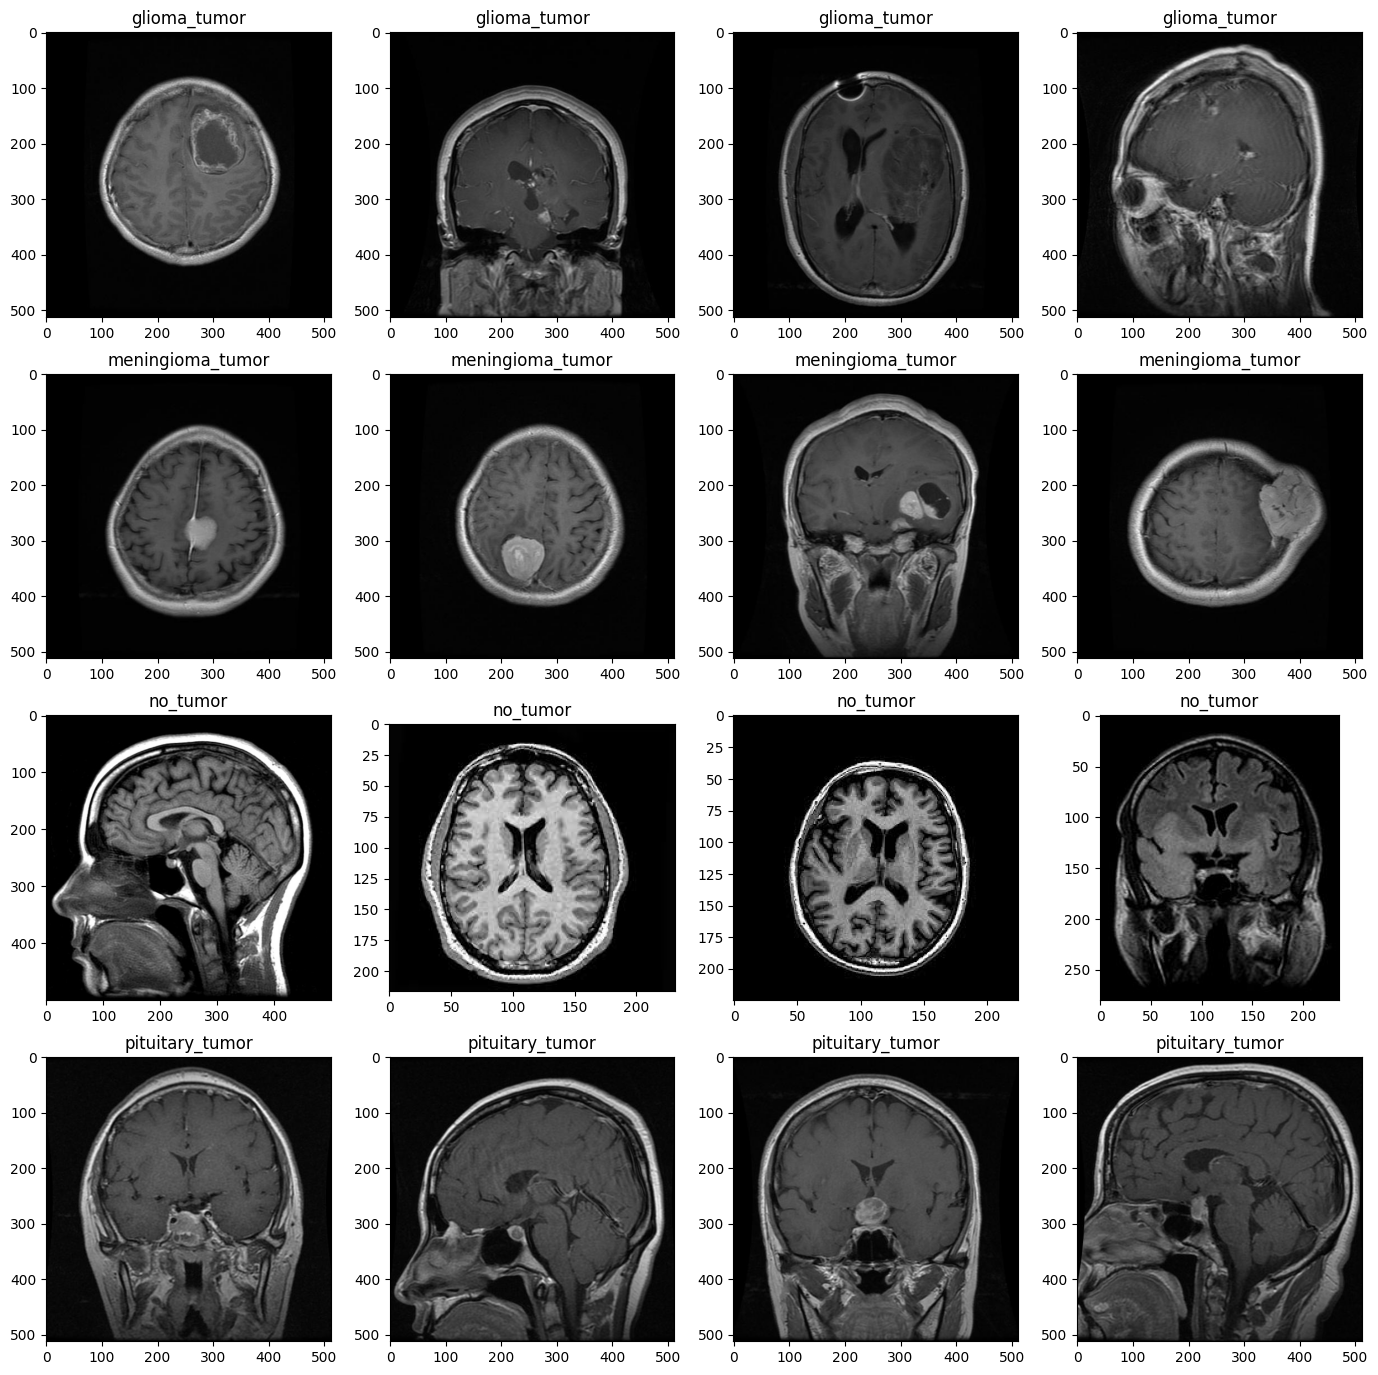

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import random

labels = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]
plt.figure(figsize = (17,17))
index = 0
dir = TRAIN_DIR
for label in labels:
  path = os.path.join(dir,label)
  images = os.listdir(path)
  for i in range(1, 5):
    img_path = os.path.join(path,images[i])
    index += 1
    plt.subplot(4, 4, index)
    plt.imshow(cv2.imread(img_path))
    plt.title(label)

In [ ]:
def preprocess_image(image, size=256):
    # Resize image
    image = cv2.resize(image, dsize=(size, size), interpolation=cv2.INTER_CUBIC)

    # Convert the image to grayscale
    #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Normalize the image
    image = image.astype(np.float32)
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    # remove images noise.
    image = cv2.bilateralFilter(image, 2, 50, 50)

    image = (image * 255).astype(np.uint8)

    return image



In [ ]:
X_train_processed = np.array([preprocess_image(img) for img in X_train])
X_test_processed = np.array([preprocess_image(img) for img in X_test])


In [ ]:
import time
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [ ]:
X_train_processed.shape

(2870, 256, 256, 3)

In [ ]:
# build the model
IMG_SHAPE = (256, 256, 3)
effnet = EfficientNetB1(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)

effnet_model = effnet.output
effnet_model = GlobalAveragePooling2D()(effnet_model)
effnet_model = Dropout(0.5)(effnet_model)
effnet_model = Dense(4, activation='softmax')(effnet_model)
effnet_model = Model(inputs=effnet.input, outputs=effnet_model)

effnet_model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 256, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 256, 256, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 256, 256, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 257, 257, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 128, 128, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 128, 128, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 128, 128, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
effnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_processed, Y_train, test_size=0.1)

In [ ]:
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(Y_test)

In [ ]:
print ("number of training samples = " + str(X_train.shape[0]))
print ("number of validation samples = " + str(X_val.shape[0]))
print ("number of test samples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val shape: " + str(X_val.shape))
print ("Y_val shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training samples = 2583
number of validation samples = 287
number of test samples = 394
X_train shape: (2583, 256, 256, 3)
Y_train shape: (2583,)
X_val shape: (287, 256, 256, 3)
Y_val shape: (287,)
X_test shape: (394, 224, 224, 3)
Y_test shape: (394,)


In [ ]:
history = effnet_model.fit(X_train, y_train, batch_size=128,
                 epochs=50,
                 validation_data=(X_val, y_val))


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 254s 5s/step - accuracy: 0.7044 - loss: 0.6840 - val_accuracy: 0.5505 - val_loss: 2.5640
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.9562 - loss: 0.1221 - val_accuracy: 0.9233 - val_loss: 0.2412
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9854 - loss: 0.0406 - val_accuracy: 0.9512 - val_loss: 0.2198
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9906 - loss: 0.0273 - val_accuracy: 0.9652 - val_loss: 0.1274
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.9746 - loss: 0.0807 - val_accuracy: 0.9443 - val_loss: 0.2033
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9891 - loss: 0.0402 - val_accuracy: 0.8537 - val_loss: 0.7034
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9908 - loss: 0.0231 - val_accuracy: 0.9512 - val_loss: 0.1616
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9949 - loss: 0.0176 - val_accuracy: 0.8

In [ ]:
def plot_metrics(history):
    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']

    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

    plt.show()

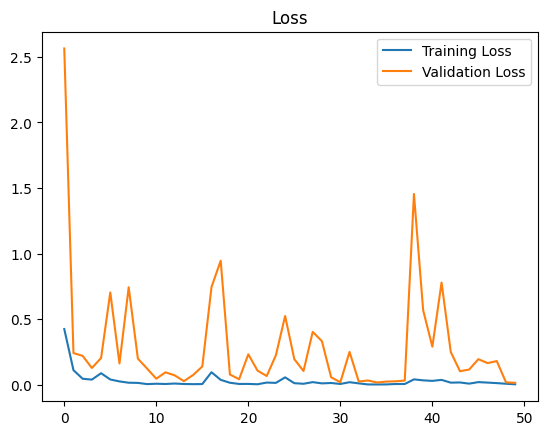

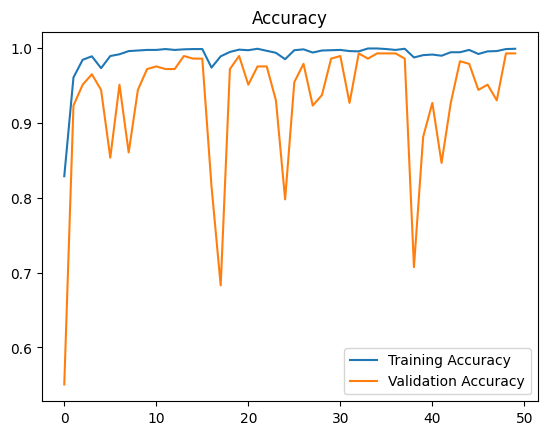

In [ ]:
history = effnet_model.history
plot_metrics(history.history)

In [ ]:
loss_test, acc_test = effnet_model.evaluate(x=X_test, y=y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 983ms/step - accuracy: 0.8020 - loss: 1.8682


# ACCURACY FOR MODEL(REAL IMAGES ONLY) = 0.8020

#TRAINING USING REAL AND GENERATED IMAGES (2870)

In [ ]:
!unzip /content/drive/MyDrive/generated_images.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: post_fine_tuning_images_A100_2870/pituitary_tumor/image_pituitary_tumor_1914.jpg  
  inflating: __MACOSX/post_fine_tuning_images_A100_2870/pituitary_tumor/._image_pituitary_tumor_1914.jpg  
  inflating: post_fine_tuning_images_A100_2870/pituitary_tumor/image_pituitary_tumor_1243.jpg  
  inflating: __MACOSX/post_fine_tuning_images_A100_2870/pituitary_tumor/._image_pituitary_tumor_1243.jpg  
  inflating: post_fine_tuning_images_A100_2870/pituitary_tumor/image_pituitary_tumor_213.jpg  
  inflating: __MACOSX/post_fine_tuning_images_A100_2870/pituitary_tumor/._image_pituitary_tumor_213.jpg  
  inflating: post_fine_tuning_images_A100_2870/pituitary_tumor/image_pituitary_tumor_575.jpg  
  inflating: __MACOSX/post_fine_tuning_images_A100_2870/pituitary_tumor/._image_pituitary_tumor_575.jpg  
  inflating: post_fine_tuning_images_A100_2870/pituitary_tumor/image_pituitary_tumor_1525.jpg  
  inflating: __MACOSX/post_f

In [ ]:
GENERATED_DIR = '/content/post_fine_tuning_images_A100_2870'

In [ ]:
generated_data = []
IMG_SIZE=256
def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(GENERATED_DIR,category)
        class_num = CATEGORIES.index(category)
        for img in tqdm(os.listdir(path)):
          img_path = os.path.join(path,img)
          if os.path.exists(img_path) and cv2.haveImageReader(img_path):
            img_array = cv2.imread(img_path ,cv2.IMREAD_COLOR)

            if img_array is not None:
              new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
              generated_data.append([new_array, class_num])
            else:
              print(f"Warning: Could not read image: {img_path}")
          else:
            print(f"Warning: Image file not found or invalid format: {img_path}")

    random.shuffle(generated_data)

create_training_data()
#np.save('train_data.npy', training_data)

print("train")
print()
X_train_generated = np.array([i[0] for i in generated_data]).reshape(-1,IMG_SIZE,IMG_SIZE,3)
Y_train_generated = [i[1] for i in generated_data]

pickle_out = open("X_train_generated.pickle","wb")
pickle.dump(X_train_generated, pickle_out)
pickle_out.close()

pickle_out = open("Y_train_generated.pickle","wb")
pickle.dump(Y_train_generated, pickle_out)
pickle_out.close()

100%|██████████| 2152/2152 [00:03<00:00, 658.60it/s]


train



In [ ]:
len(X_train_generated), len(Y_train_generated)

(400, 400)

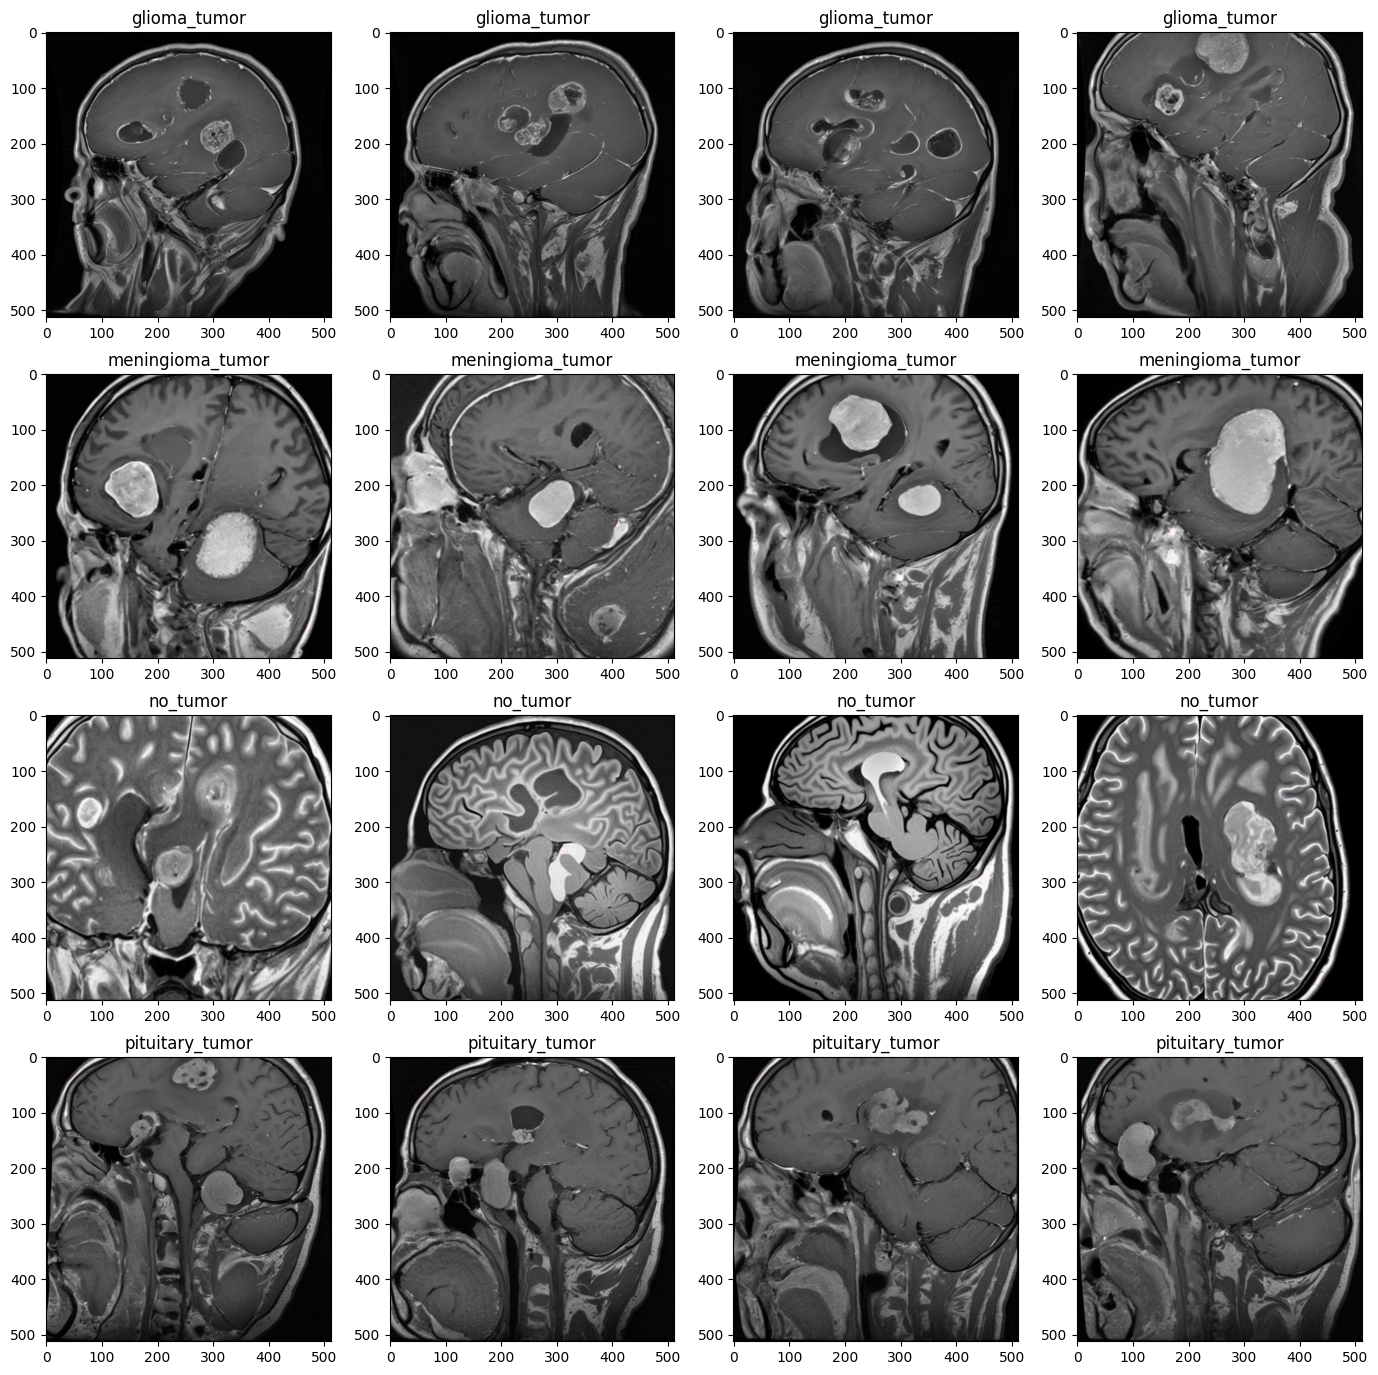

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import random

labels = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]
plt.figure(figsize = (17,17))
index = 0
dir = GENERATED_DIR
for label in labels:
  path = os.path.join(dir,label)
  images = os.listdir(path)
  for i in range(1, 5):
    img_path = os.path.join(path,images[i])
    index += 1
    plt.subplot(4, 4, index)
    plt.imshow(cv2.imread(img_path))
    plt.title(label)

In [ ]:
X_generated_processed = np.array([preprocess_image(img) for img in X_train_generated])

In [ ]:
X_train.shape, X_generated_processed.shape

((2870, 224, 224, 3), (800, 256, 256, 3))

In [ ]:
X_real_generated = np.concatenate((X_train_processed, X_generated_processed), axis=0)
Y_real_generated = np.concatenate((Y_train, Y_train_generated), axis=0)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_real_generated, Y_real_generated, test_size=0.1)

In [ ]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((2616, 256, 256, 3), (654, 256, 256, 3), (2616,), (654,))

In [ ]:
IMG_SHAPE = (256, 256, 3)
effnet = EfficientNetB1(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)

effnet_model = effnet.output
effnet_model = GlobalAveragePooling2D()(effnet_model)
effnet_model = Dropout(0.5)(effnet_model)
effnet_model = Dense(4, activation='softmax')(effnet_model)
effnet_model = Model(inputs=effnet.input, outputs=effnet_model)

effnet_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_14 (Rescaling)  │ (None, 256, 256, 3)    │              0 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_7           │ (None, 256, 256, 3)    │              7 │ rescaling_14[0][0]     │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_15 (Rescaling)  │ (None, 256, 256, 3)    │              0 │ normalization_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 257, 257, 3)    │              0 │ rescaling_15[0][0]     │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 128, 128, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 128, 128, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 128, 128, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
effnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
X_val.shape, y_val.shape

((287, 256, 256, 3), (287,))

In [ ]:
history = effnet_model.fit(X_train, y_train, batch_size=32,
                 epochs=30,
                 validation_data=(X_val, y_val))

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.7736 - loss: 0.5522 - val_accuracy: 0.8654 - val_loss: 0.4102
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9485 - loss: 0.1532 - val_accuracy: 0.9602 - val_loss: 0.1677
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9650 - loss: 0.0992 - val_accuracy: 0.9450 - val_loss: 0.1654
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9819 - loss: 0.0538 - val_accuracy: 0.9725 - val_loss: 0.0960
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9841 - loss: 0.0625 - val_accuracy: 0.9541 - val_loss: 0.1206
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9762 - loss: 0.0653 - val_accuracy: 0.9786 - val_loss: 0.1040
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9879 - loss: 0.0302 - val_accuracy: 0.9541 - val_loss: 0.1888
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9919 - loss: 0.0219 - val_accuracy: 0.9419 - v

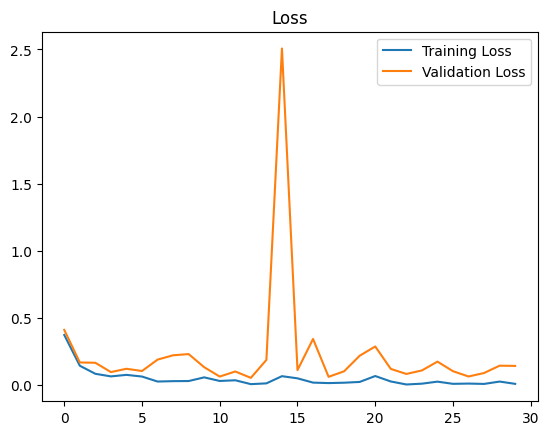

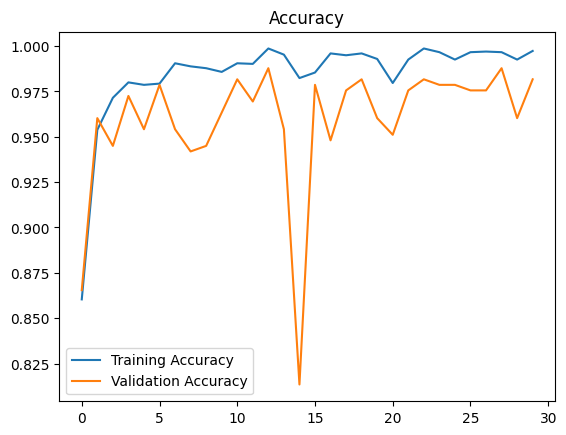

In [ ]:
history = effnet_model.history
plot_metrics(history.history)

In [ ]:
loss_test, acc_test = effnet_model.evaluate(x=X_test, y=y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 395ms/step - accuracy: 0.7398 - loss: 2.8725


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

In [ ]:
model = models.resnet50(pretrained=True).to("cuda")
model.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_embedding(frame):
    frame = Image.fromarray(frame)
    frame = preprocess(frame)
    frame = frame.unsqueeze(0)


    with torch.no_grad():
        embedding = model(frame.to("cuda"))[0]
    return embedding.cpu().numpy()


embeddings = [get_embedding(frame) for frame in X_train]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
real_features = np.array(embeddings)

In [ ]:
import cv2
from PIL import Image
from google.colab.patches import cv2_imshow

import torch
from torchvision import models, transforms

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx
from networkx.algorithms.approximation import traveling_salesman_problem

In [ ]:
embeddings_generated = [get_embedding(frame) for frame in X_train_generated]

In [ ]:
synthetic_features = np.array(embeddings_generated)

In [ ]:
import numpy as np

# Объединяем эмбеддинги
all_features = np.vstack((real_features, synthetic_features))

# Создаём метки для идентификации: 0 - реальные, 1 - синтетика
labels = np.array([0] * len(real_features) + [1] * len(synthetic_features))


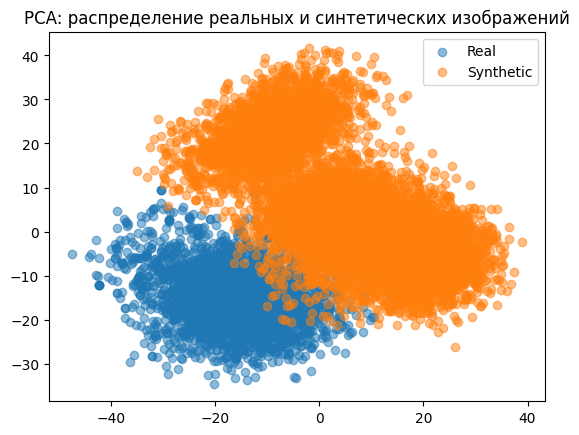

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Используем PCA для снижения размерности до 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_features)

# Визуализация
plt.scatter(features_2d[:len(real_features), 0], features_2d[:len(real_features), 1], label="Real", alpha=0.5)
plt.scatter(features_2d[len(real_features):, 0], features_2d[len(real_features):, 1], label="Synthetic", alpha=0.5)
plt.legend()
plt.title("PCA: распределение реальных и синтетических изображений")
plt.show()


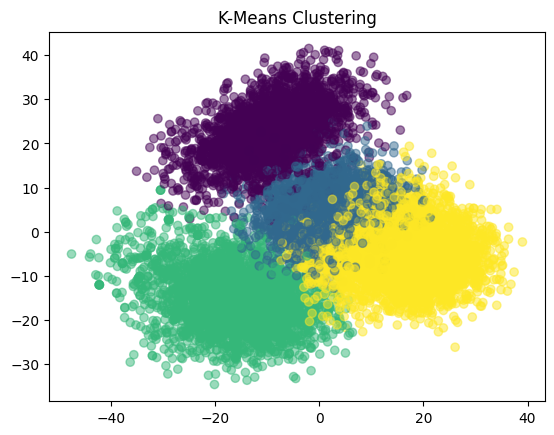

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 4  # Укажите количество классов (например, 4, если у вас 4 целевых класса)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(all_features)

# Визуализируем кластеры
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clusters, cmap="viridis", alpha=0.5)
plt.title("K-Means Clustering")
plt.show()


In [ ]:
from scipy.linalg import sqrtm
import numpy as np

def calculate_fid(real_features, synthetic_features):
    mu1, sigma1 = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = np.mean(synthetic_features, axis=0), np.cov(synthetic_features, rowvar=False)
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

fid_score = calculate_fid(real_features, synthetic_features)
print(f"FID Score: {fid_score}")


FID Score: 1419.097436748025
